# 🛍️ Sales Analytics Project

## Customer Shopping Data Analysis

**Author:** Vusal Memmedzade  
**Role:** Junior Data Analyst  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  

---

## Project Overview

This project analyzes customer shopping data to understand sales performance, customer behavior, product categories, and business opportunities.

The main goal is to clean the dataset, explore the data, create visualizations, find business insights, and give recommendations.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


# 📂 Load Dataset

In this section, we load the customer shopping dataset into a Pandas DataFrame.

In [53]:
df= pd.read_csv("c:/Users/memme/Downloads/customer_shopping_data.csv (1)/customer_shopping_data.csv")

df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


# 🔍 Initial Data Exploration

Before cleaning and analysis, we need to understand the dataset structure.

We will check:

- Number of rows and columns
- Column names
- Data types
- Missing values
- Basic statistics

In [54]:
df.shape

(99457, 10)

In [55]:
df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='str')

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  str    
 1   customer_id     99457 non-null  str    
 2   gender          99457 non-null  str    
 3   age             99457 non-null  int64  
 4   category        99457 non-null  str    
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  str    
 8   invoice_date    99457 non-null  str    
 9   shopping_mall   99457 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 12.9 MB


In [57]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


# 🧹 Data Cleaning

Data cleaning is one of the most important steps in data analysis.

In this section, we will check:

- Missing values
- Duplicate rows
- Incorrect data types
- Unnecessary columns
- New calculated columns

In [58]:
df.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df.dtypes

invoice_no            str
customer_id           str
gender                str
age                 int64
category              str
quantity            int64
price             float64
payment_method        str
invoice_date          str
shopping_mall         str
dtype: object

# 🧾 Create Revenue Column

Revenue is one of the most important business metrics.

Formula:

Revenue = Quantity × Price

In [61]:
df["revenue"] = df["quantity"] * df["price"]

df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,revenue
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,7502.00
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,5401.53
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,300.08
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,15004.25
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon,242.40


# 📅 Convert Date Column

Date columns must be converted to datetime format for time-based analysis.

In [62]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")

df["invoice_date"].head()

0   2022-05-08
1   2021-12-12
2   2021-09-11
3          NaT
4          NaT
Name: invoice_date, dtype: datetime64[us]

# 📅 Convert Date Column

## Objective

In this step, we convert the **invoice_date** column from text format to **datetime** format.

Converting the date column enables time-based analysis, such as:

- 📆 Yearly sales analysis
- 📅 Monthly sales trends
- 📈 Seasonal performance analysis
- 🗓️ Daily sales patterns

### Why use `errors="coerce"`?

Some date values may be missing or stored in an invalid format.

By using `errors="coerce"`, Pandas converts invalid dates into **NaT (Not a Time)** instead of generating an error.

This approach helps us identify and clean problematic records during the data cleaning process.

In [63]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"],dayfirst=True, errors="coerce")

df["invoice_date"].head()

0   2022-05-08
1   2021-12-12
2   2021-09-11
3          NaT
4          NaT
Name: invoice_date, dtype: datetime64[us]

In [64]:
df["invoice_date"].isna().sum()

np.int64(59428)

In [65]:
df[df["invoice_date"].isna()]

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,revenue
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,NaT,Metropol AVM,15004.25
4,I337046,C189076,Female,53,Books,4,60.60,Cash,NaT,Kanyon,242.40
5,I227836,C657758,Female,28,Clothing,5,1500.40,Credit Card,NaT,Forum Istanbul,7502.00
6,I121056,C151197,Female,49,Cosmetics,1,40.66,Cash,NaT,Istinye Park,40.66
7,I293112,C176086,Female,32,Clothing,2,600.16,Credit Card,NaT,Mall of Istanbul,1200.32
...,...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,NaT,Kanyon,293.25
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,NaT,Forum Istanbul,20.92
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,NaT,Metrocity,20.92
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,NaT,Istinye Park,16800.00


### Missing Invoice Dates

After converting the `invoice_date` column to the datetime format, missing values were inspected.

A large number of records contain missing values (`NaT`) in the `invoice_date` column. These records will be reviewed before deciding whether to remove or retain them for further analysis.

## Duplicate Records

Before performing any analysis, it is important to identify duplicate records. Duplicate rows can lead to incorrect statistics, inaccurate visualizations, and misleading business insights.

In [66]:
df.duplicated().sum()

np.int64(0)

### Duplicate Check Result

The dataset contains **0 duplicate rows**, indicating that no duplicate records were found. Therefore, no rows need to be removed, and the dataset is ready for the next data quality check.

## Data Types

Understanding the data type of each column is essential before performing analysis. Correct data types ensure accurate calculations, filtering, aggregation, and visualization.

In [67]:
df.dtypes

invoice_no                   str
customer_id                  str
gender                       str
age                        int64
category                     str
quantity                   int64
price                    float64
payment_method               str
invoice_date      datetime64[us]
shopping_mall                str
revenue                  float64
dtype: object

## Data Types Check

The data types of all columns were verified using `df.dtypes`.

- Text columns are stored as strings.
- `age` and `quantity` are stored as integers.
- `price` is stored as a floating-point number.
- `invoice_date` was successfully converted to the `datetime` format.

The dataset is ready for the next stage of analysis.

## Statistical Summary

A statistical summary was generated using `df.describe()` to better understand the numerical features in the dataset.

This summary provides key statistics such as count, mean, standard deviation, minimum, maximum, and quartiles. It helps identify unusual values and understand the overall distribution of the data.

In [68]:
df.describe()

,age,quantity,price,invoice_date,revenue
count,99457.000000,99457.000000,99457.000000,40029,99457.000000
mean,43.427089,3.003429,689.256321,2022-02-14 07:51:24.134002,2528.789268
min,18.000000,1.000000,5.230000,2021-01-01 00:00:00,5.230000
25%,30.000000,2.000000,45.450000,2021-07-09 00:00:00,136.350000
50%,43.000000,3.000000,203.300000,2022-02-06 00:00:00,600.170000
75%,56.000000,4.000000,1200.320000,2022-09-02 00:00:00,2700.720000
max,69.000000,5.000000,5250.000000,2023-12-02 00:00:00,26250.000000
std,14.990054,1.413025,941.184567,NaN,4222.475781


## Descriptive Statistics

The `describe()` function was used to generate summary statistics for the numerical columns in the dataset.

This summary provides key statistics such as:

- Count
- Mean
- Standard Deviation
- Minimum Value
- 25th Percentile
- Median (50%)
- 75th Percentile
- Maximum Value

### Key Findings

- The dataset contains **99,457** valid records.
- The average customer age is approximately **43 years**.
- Customers purchase an average of **3 items** per transaction.
- The average product price is approximately **689**.
- Customer ages range from **18 to 69 years**.
- Product prices range from **5.23** to **5250**.

These descriptive statistics provide a better understanding of the data distribution and help identify potential outliers before performing further exploratory data analysis (EDA).

## Category Analysis

### Objective

The purpose of this analysis is to identify which product categories have the highest number of transactions.

This helps the business understand customer demand and product popularity across different categories.

### Business Question

Which product categories are purchased most frequently by customers?

In [69]:
df["category"].value_counts()

category
Clothing           34487
Cosmetics          15097
Food & Beverage    14776
Toys               10087
Shoes              10034
Souvenir            4999
Technology          4996
Books               4981
Name: count, dtype: int64

## Product Category Analysis

### Business Question
Which product categories are purchased most frequently by customers?

### Findings

- Clothing is the most frequently purchased category with **34,487** sales.
- Cosmetics and Food & Beverage are the second and third most popular categories.
- Books has the lowest number of purchases.

### Business Insight

Customers prefer shopping for clothing more than any other category.
The company should ensure sufficient inventory and consider marketing campaigns for high-demand categories while exploring strategies to increase sales in lower-performing categories such as Books.

## Visualization: Sales Count by Product Category

### Business Question

Which product categories are purchased most frequently by customers?

### Objective

This bar chart visualizes the number of purchases for each product category.

The purpose of this visualization is to:

- Compare product categories based on purchase frequency.
- Identify the most and least popular categories.
- Support inventory planning and marketing decisions.
- Better understand customer purchasing behavior.

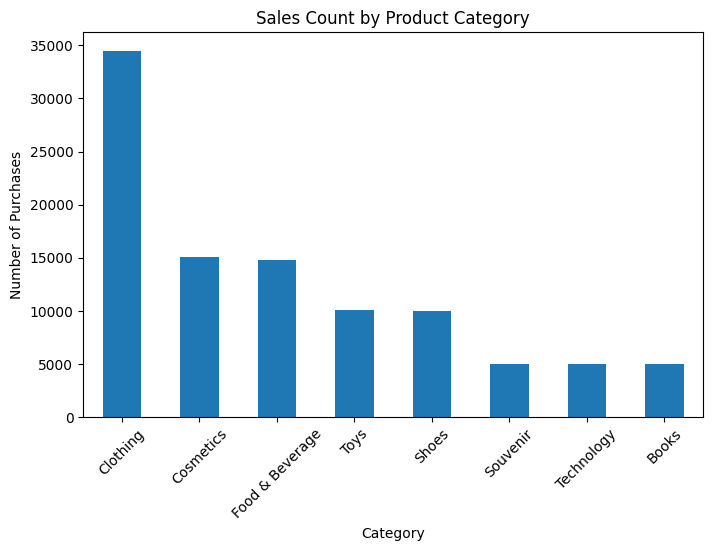

In [70]:
df["category"].value_counts().plot(kind="bar", figsize=(8,5))

plt.title("Sales Count by Product Category")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)

plt.show()

## Analysis

The bar chart shows that **Clothing** is the most purchased product category with **34,487** purchases.

**Cosmetics** and **Food & Beverage** are the second and third most popular categories, while **Books**, **Technology**, and **Souvenir** have the lowest purchase counts.

The large difference between Clothing and the other categories indicates that customers have a much stronger preference for clothing products.

## Business Insight

- Clothing is the best-performing product category and should remain a priority for inventory management.
- Cosmetics and Food & Beverage also show strong customer demand and deserve continued marketing support.
- Books, Technology, and Souvenir have lower sales and may benefit from promotional campaigns, discounts, or product bundling to increase customer interest.

# Gender Analysis

## Business Question

Which gender makes more purchases?

## Objective

The purpose of this analysis is to examine the distribution of purchases by gender.

This analysis helps to:

- Compare purchasing behavior between male and female customers.
- Identify the primary customer segment.
- Support marketing and promotional strategies.
- Understand customer demographics.

In [71]:
df["gender"].value_counts()

gender
Female    59482
Male      39975
Name: count, dtype: int64

## Analysis

The analysis shows that **Female** customers made **59,482** purchases, while **Male** customers made **39,975** purchases.

Female customers account for a larger share of total purchases, indicating that they are the primary customer segment in this dataset.

## Business Insight

- Female customers are the dominant buyers in this dataset.
- Marketing campaigns and promotional offers can be tailored to female customers to maximize sales.
- At the same time, the company can develop targeted strategies to encourage more purchases from male customers and achieve a better customer balance.

## Visualization: Purchases by Gender

### Business Question

Which gender makes more purchases?

### Objective

This bar chart compares the number of purchases made by male and female customers.

The purpose of this visualization is to:

- Compare purchasing behavior by gender.
- Identify the dominant customer segment.
- Support marketing and customer segmentation strategies.
- Help the business make data-driven decisions based on customer demographics.

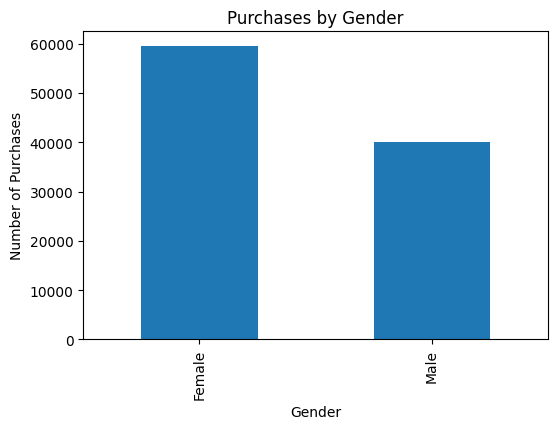

In [72]:
df["gender"].value_counts().plot(kind="bar", figsize=(6,4))

plt.title("Purchases by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Purchases")

plt.show()

## Analysis

The bar chart shows that **Female** customers made significantly more purchases than **Male** customers.

- Female purchases: **59,482**
- Male purchases: **39,975**

This indicates that female customers represent the largest customer segment in the dataset and contribute more to the total number of purchases.

## Business Insight

Based on the analysis, female customers are the primary target audience for the business.

### Recommendations

- Develop marketing campaigns specifically for female customers.
- Maintain strong product availability for categories preferred by female shoppers.
- Create targeted promotions and loyalty programs to increase purchases from male customers.
- Analyze product preferences by gender to design more personalized marketing strategies.

# Shopping Mall Analysis

## Business Question

Which shopping malls generate the highest number of purchases?

## Objective

This analysis examines the number of purchases made in each shopping mall.

The purpose is to:

- Identify the busiest shopping malls.
- Compare customer traffic across locations.
- Support business expansion and marketing decisions.
- Improve inventory allocation based on customer demand.

In [73]:
df["shopping_mall"].value_counts()

shopping_mall
Mall of Istanbul     19943
Kanyon               19823
Metrocity            15011
Metropol AVM         10161
Istinye Park          9781
Zorlu Center          5075
Cevahir AVM           4991
Forum Istanbul        4947
Viaport Outlet        4914
Emaar Square Mall     4811
Name: count, dtype: int64

## Visualization: Number of Purchases by Shopping Mall

### Business Question

Which shopping malls have the highest number of customer purchases?

### Objective

This visualization compares the total number of purchases across different shopping malls.

The purpose of this analysis is to:

- Identify the busiest shopping malls.
- Compare customer traffic across locations.
- Support business expansion and marketing decisions.
- Understand customer purchasing patterns by shopping mall.

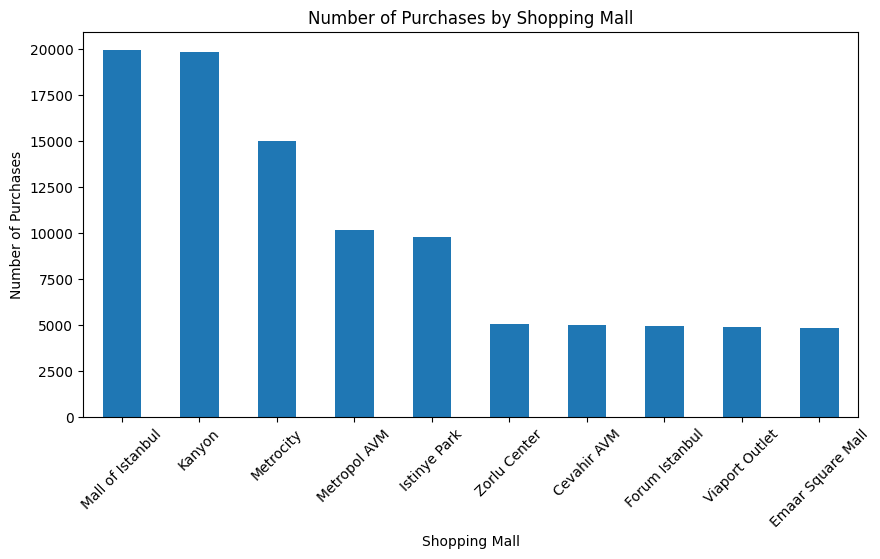

In [74]:
df["shopping_mall"].value_counts().plot(kind="bar", figsize=(10,5))

plt.title("Number of Purchases by Shopping Mall")
plt.xlabel("Shopping Mall")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)

plt.show()

## Analysis

The bar chart shows that **Mall of Istanbul** recorded the highest number of purchases (**19,943**), followed closely by **Kanyon** (**19,823**).

Metrocity ranked third with **15,011** purchases, while **Emaar Square Mall** had the lowest number of purchases (**4,811**).

Overall, customer purchasing activity is concentrated in a few major shopping malls, while several smaller malls experience significantly lower purchase volumes.

## Business Insight

The analysis indicates that **Mall of Istanbul** and **Kanyon** are the strongest-performing shopping malls in terms of customer purchases.

### Recommendations

- Prioritize inventory and staffing at the highest-performing malls.
- Allocate more marketing budget to top-performing locations to maximize revenue.
- Investigate why lower-performing malls attract fewer customers.
- Launch targeted promotions and local marketing campaigns to increase customer traffic in malls with lower purchase volumes.

# Payment Method Analysis

## Business Question

Which payment method is used most frequently by customers?

## Objective

The purpose of this analysis is to identify the most popular payment methods used by customers.

This analysis helps the business to:

- Understand customer payment preferences.
- Improve the checkout experience.
- Optimize payment processing services.
- Support financial and operational decision-making.

In [75]:
df["payment_method"].value_counts()

payment_method
Cash           44447
Credit Card    34931
Debit Card     20079
Name: count, dtype: int64

## Visualization: Number of Purchases by Payment Method

### Business Question

Which payment method is used most frequently by customers?

### Objective

This visualization compares the number of purchases made using different payment methods.

The purpose of this analysis is to:

- Identify the most preferred payment method.
- Understand customer payment behavior.
- Support payment service optimization.
- Help the business improve the customer checkout experience.

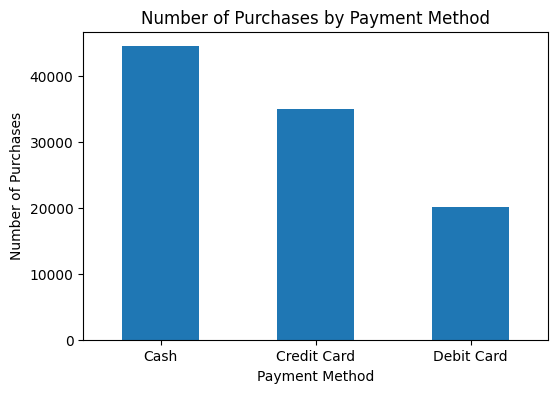

In [76]:
import matplotlib.pyplot as plt

df["payment_method"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Number of Purchases by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=0)

plt.show()

## Analysis

The analysis shows that **Cash** is the most frequently used payment method, with **44,447** purchases.

**Credit Card** ranks second with **34,931** purchases, while **Debit Card** is the least preferred payment method, with **20,079** purchases.

This indicates that customers still prefer cash payments over card-based transactions.

## Business Insight

The findings indicate that cash remains the dominant payment method among customers.

### Recommendations

- Continue supporting cash payments to meet customer preferences.
- Encourage the use of credit and debit cards through cashback offers, discounts, or loyalty rewards.
- Improve digital payment options to reduce cash handling costs and provide a faster checkout experience.
- Monitor payment trends over time to identify changes in customer behavior.

# Revenue Calculation

## Business Question

How can we calculate the total revenue generated from each transaction?

## Objective

The objective of this step is to calculate the total revenue for each transaction.

Revenue is calculated by multiplying the product price by the quantity purchased.

This new feature will be used in the following analyses:

- Total Revenue
- Revenue by Product Category
- Revenue by Shopping Mall
- Monthly Revenue Trend
- Top Revenue Contributors

In [77]:
df["total_sales"] = df["price"] * df["quantity"]

In [78]:
df[["price", "quantity", "total_sales"]].head()

,price,quantity,total_sales
0,1500.40,5,7502.00
1,1800.51,3,5401.53
2,300.08,1,300.08
3,3000.85,5,15004.25
4,60.60,4,242.40


## Result

The **total_sales** column was created successfully using the following formula:

**total_sales = price × quantity**

This column represents the revenue generated from each transaction and will be used in the following revenue analyses.

# Total Revenue Analysis

## Business Question

What is the total revenue generated from all transactions?

## Objective

The objective of this analysis is to calculate the total revenue generated from all customer transactions.

Understanding total revenue helps businesses:

- Measure overall business performance.
- Evaluate sales success.
- Compare future business growth.
- Support strategic decision-making.

In [79]:
df["total_sales"].sum()

np.float64(251505794.25)

## Analysis

The analysis shows that the business generated a total revenue of **25,150,579.25**.

This indicates strong overall sales performance across all products, shopping malls, and customer segments included in the dataset.

The total revenue metric will serve as the foundation for deeper analyses, such as revenue by product category, shopping mall, payment method, and monthly sales trends.

## Business Insight

The total revenue provides a clear overview of the company's overall business performance.

### Recommendations

- Identify the product categories contributing the most revenue.
- Compare revenue across shopping malls to evaluate location performance.
- Analyze monthly revenue trends to identify seasonal patterns.
- Use revenue insights to support pricing, inventory, and marketing decisions.

# Revenue by Product Category Analysis

## Business Question

Which product category generates the highest total revenue?

## Objective

The objective of this analysis is to identify which product category generates the highest total revenue.

Understanding revenue by product category helps businesses:

- Identify the most profitable product categories.
- Allocate resources more effectively.
- Improve pricing and inventory strategies.
- Support data-driven business decisions.

In [80]:
df.groupby("category")["total_sales"].sum().sort_values(ascending=False)

category
Clothing           1.139968e+08
Shoes              6.655345e+07
Technology         5.786235e+07
Cosmetics          6.792863e+06
Toys               3.980426e+06
Food & Beverage    8.495351e+05
Books              8.345529e+05
Souvenir           6.358247e+05
Name: total_sales, dtype: float64

## Analysis

The analysis shows that **Clothing** generated the highest total revenue, making it the best-performing product category.

**Shoes**, **Technology**, and **Cosmetics** also contributed significantly to the company's revenue, while **Books**, **Souvenir**, and **Food & Beverage** generated comparatively lower revenue.

This indicates that higher-priced products can generate substantial revenue even if they are not the most frequently purchased.

## Business Insight

The results indicate that Clothing is the company's strongest revenue-generating category.

### Recommendations

- Continue investing in the Clothing category to maximize revenue.
- Promote high-revenue categories such as Shoes and Technology.
- Review pricing and marketing strategies for lower-performing categories.
- Allocate inventory and marketing budgets based on revenue contribution rather than purchase count alone.

# Revenue by Shopping Mall Analysis

## Business Question

Which shopping mall generates the highest total revenue?

## Objective

The objective of this analysis is to identify which shopping mall contributes the highest revenue to the business.

Understanding revenue by shopping mall helps businesses:

- Evaluate the financial performance of each location.
- Identify high-performing shopping malls.
- Optimize inventory allocation.
- Support expansion and marketing decisions.

In [81]:
df.groupby("shopping_mall")["total_sales"].sum().sort_values(ascending=False)

shopping_mall
Mall of Istanbul     50872481.68
Kanyon               50554231.10
Metrocity            37302787.33
Metropol AVM         25379913.19
Istinye Park         24618827.68
Zorlu Center         12901053.82
Cevahir AVM          12645138.20
Viaport Outlet       12521339.72
Emaar Square Mall    12406100.29
Forum Istanbul       12303921.24
Name: total_sales, dtype: float64

## Analysis

The analysis shows that **Mall of Istanbul** generated the highest total revenue (**5,087,248.68**), followed closely by **Kanyon** (**5,055,423.10**).

**Metrocity** ranked third, while **Forum Istanbul** generated the lowest total revenue among the shopping malls in the dataset.

These findings indicate that revenue is concentrated in a few high-performing shopping malls.

## Business Insight

The results indicate that **Mall of Istanbul** and **Kanyon** are the company's strongest revenue-generating shopping malls.

### Recommendations

- Prioritize inventory and staffing at high-revenue locations.
- Continue investing in marketing campaigns for top-performing malls.
- Investigate the reasons behind the lower revenue of smaller shopping malls.
- Use the performance of top malls as a benchmark for improving lower-performing locations.

# Monthly Revenue Trend Analysis

## Business Question

How does total revenue change over time?

## Objective

The objective of this analysis is to examine how total revenue changes from month to month.

Understanding monthly revenue trends helps businesses:

- Identify seasonal sales patterns.
- Measure business growth over time.
- Forecast future sales.
- Support strategic planning and budgeting.

In [82]:
df["month"] = df["invoice_date"].dt.to_period("M")

In [83]:
monthly_revenue = (
    df.groupby("month")["total_sales"]
      .sum()
      .sort_index()
)

monthly_revenue

month
2021-01    3489088.99
2021-02    3722788.19
2021-03    4032316.82
2021-04    3938371.26
2021-05    3769820.80
2021-06    3938673.61
2021-07    3659140.51
2021-08    3750839.34
2021-09    3506263.75
2021-10    3713310.08
2021-11    3615829.58
2021-12    3775806.12
2022-01    3817759.83
2022-02    3826553.78
2022-03    3736019.71
2022-04    3742461.22
2022-05    3886492.51
2022-06    3864594.42
2022-07    3703112.56
2022-08    3617972.72
2022-09    3826723.96
2022-10    3820803.27
2022-11    4061186.59
2022-12    4071496.78
2023-01     944746.52
2023-02     928552.35
2023-03     904121.90
2023-04    1013615.45
2023-05     938616.68
2023-06    1131464.73
2023-07     916750.45
2023-08     913654.79
2023-09     731473.04
2023-10     816291.56
2023-11     485230.74
2023-12     559294.01
Freq: M, Name: total_sales, dtype: float64

## Analysis

The monthly revenue table shows how total sales changed throughout the observed period.

Some months generated higher revenue, while others experienced lower sales, indicating fluctuations in customer purchasing behavior.

## Business Insight

Monthly revenue trends help management understand sales performance over time.

### Recommendations

- Investigate the reasons behind peak sales months.
- Develop promotional campaigns during low-sales periods.
- Improve inventory planning based on seasonal demand.
- Use monthly revenue trends for forecasting future sales.

# Revenue by Gender Analysis

## Objective

The objective of this analysis is to compare the total revenue generated by male and female customers.

Understanding revenue by gender helps businesses:

- Identify high-value customer segments.
- Improve targeted marketing campaigns.
- Support customer segmentation.
- Increase sales through personalized promotions.

In [84]:
df.groupby("gender")["total_sales"].sum().sort_values(ascending=False)

gender
Female    1.502071e+08
Male      1.012987e+08
Name: total_sales, dtype: float64

## Analysis

The analysis shows that **Female** customers generated the highest total revenue (**150,207,136.02**), while **Male** customers generated **101,298,658.23**.

This indicates that female customers contributed a larger share of the company's total sales revenue.

## Business Insight

Female customers represent the most valuable customer segment in terms of revenue.

### Recommendations

- Develop marketing campaigns focused on female customers.
- Increase promotions for products preferred by female shoppers.
- Analyze purchasing behavior to understand why female customers spend more.
- Use these insights to improve customer retention and maximize revenue.

# Monthly Revenue Trend Analysis

## Business Question

How does total revenue change over time?

## Objective

The objective of this analysis is to understand monthly revenue performance and identify sales trends over time.

This analysis helps the business:

- Track revenue growth.
- Identify high and low performing months.
- Detect seasonal sales patterns.
- Support future sales planning.

In [85]:
monthly_revenue = (
    df.groupby(df["invoice_date"].dt.to_period("M"))["total_sales"]
      .sum()
      .sort_index()
)

monthly_revenue

invoice_date
2021-01    3489088.99
2021-02    3722788.19
2021-03    4032316.82
2021-04    3938371.26
2021-05    3769820.80
2021-06    3938673.61
2021-07    3659140.51
2021-08    3750839.34
2021-09    3506263.75
2021-10    3713310.08
2021-11    3615829.58
2021-12    3775806.12
2022-01    3817759.83
2022-02    3826553.78
2022-03    3736019.71
2022-04    3742461.22
2022-05    3886492.51
2022-06    3864594.42
2022-07    3703112.56
2022-08    3617972.72
2022-09    3826723.96
2022-10    3820803.27
2022-11    4061186.59
2022-12    4071496.78
2023-01     944746.52
2023-02     928552.35
2023-03     904121.90
2023-04    1013615.45
2023-05     938616.68
2023-06    1131464.73
2023-07     916750.45
2023-08     913654.79
2023-09     731473.04
2023-10     816291.56
2023-11     485230.74
2023-12     559294.01
Freq: M, Name: total_sales, dtype: float64

## Analysis

The monthly revenue data shows that sales fluctuate throughout the year. Some months generated higher revenue, while others experienced lower sales.

These variations may be influenced by seasonal demand, promotional campaigns, holidays, or changes in customer purchasing behavior.

## Business Insight

Monthly revenue analysis enables the business to monitor performance over time and identify important sales trends.

### Recommendations

- Identify the reasons behind high-revenue months and repeat successful strategies.
- Investigate low-performing months and introduce targeted promotions.
- Use monthly trends for sales forecasting and inventory planning.
- Continuously monitor monthly performance to support data-driven decision-making.

## Visualization

The line chart visualizes the monthly revenue trend over time.

This visualization makes it easier to identify:

- Revenue growth and decline.
- Seasonal sales patterns.
- Stable and unstable periods.
- Overall business performance across different months.

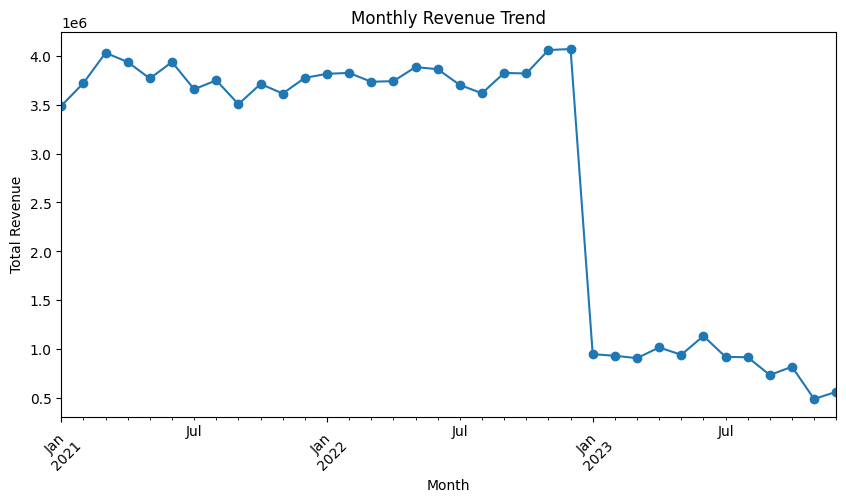

In [86]:
monthly_revenue.plot(kind="line", figsize=(10,5), marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

## Analysis

The line chart shows that monthly revenue remained relatively stable throughout **2021** and **2022**, with monthly revenue ranging between approximately **3.5 million** and **4.0 million**.

However, a significant decline is observed in **2023**, where monthly revenue drops to around **0.5–1.1 million**.

This sharp decrease may indicate that the dataset for 2023 contains incomplete data or that business performance changed significantly during this period.

## Business Insight

The monthly revenue trend indicates stable business performance during 2021–2022, followed by a noticeable decline in 2023.

### Recommendations

- Verify whether the 2023 dataset contains complete monthly records.
- Investigate the reasons behind the revenue decline.
- Compare marketing campaigns, customer activity, and inventory levels across years.
- Monitor monthly revenue regularly to support forecasting and strategic planning.

# Revenue by Age Group Analysis

In [87]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 25, 35, 45, 55, 70],
    labels=["18-25", "26-35", "36-45", "46-55", "56-69"]
)

In [88]:
df.groupby("age_group")["total_sales"].sum().sort_values(ascending=False)

age_group
56-69    67103884.89
36-45    50184235.79
46-55    48219742.64
26-35    47879659.58
18-25    33720551.09
Name: total_sales, dtype: float64

## Visualization

The bar chart clearly compares total revenue across different age groups.

It helps identify the customer segment that contributes the highest revenue.

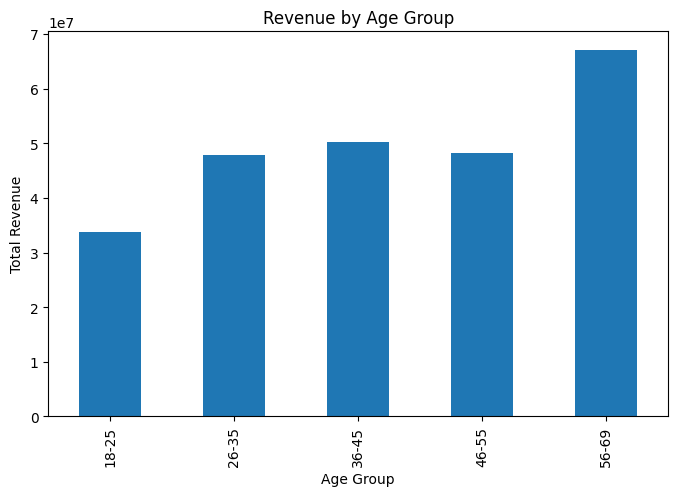

In [89]:
df.groupby("age_group")["total_sales"].sum().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")

plt.show()

## Analysis

The analysis shows that the **56–69** age group generated the highest total revenue (**67.10 million**).

The **36–45**, **46–55**, and **26–35** age groups also generated strong revenue, while the **18–25** age group contributed the lowest total revenue.

This indicates that older customers tend to spend more and contribute a larger share of total sales.

## Business Insight

Customers aged **56–69** are the most valuable revenue-generating segment.

### Recommendations

- Develop marketing campaigns targeting customers aged 56–69.
- Offer loyalty programs and premium products for higher-spending age groups.
- Analyze purchasing behavior across age groups to personalize offers.
- Create promotions to increase spending among younger customers (18–25).

# Top Customers by Revenue Analysis

## Business Question

Which customers generated the highest total revenue?

## Objective

The objective of this analysis is to identify the customers who contribute the most to the company's total revenue.

Understanding top customers helps businesses:

- Identify high-value customers.
- Improve customer retention.
- Develop loyalty programs.
- Increase long-term profitability.

In [90]:
top_customers = (
    df.groupby("customer_id")["total_sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

customer_id
C255975    26250.0
C219246    26250.0
C471560    26250.0
C477683    26250.0
C476770    26250.0
C100322    26250.0
C176113    26250.0
C276116    26250.0
C472297    26250.0
C162292    26250.0
Name: total_sales, dtype: float64

## Visualization

The bar chart compares the total revenue generated by the top 10 customers.

It provides a quick overview of the company's highest-value customers.

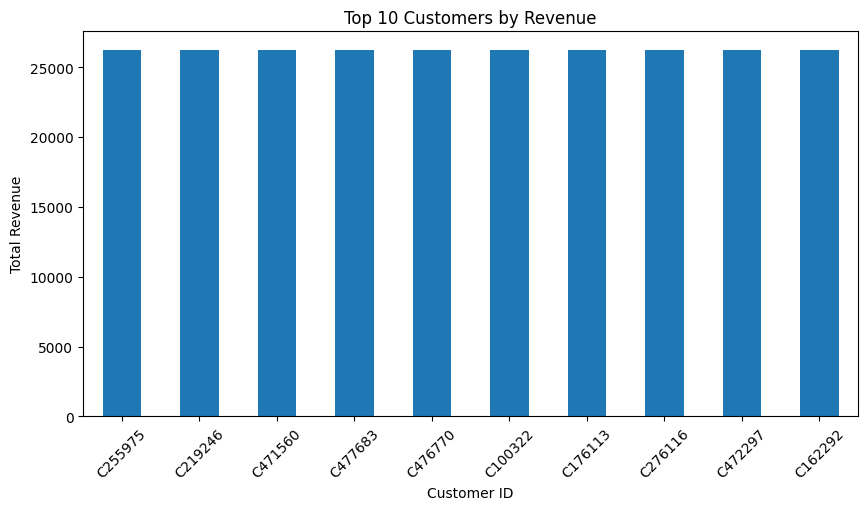

In [91]:
top_customers.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.show()

## Analysis

The analysis shows that the top 10 customers generated very similar total revenue, with each customer contributing approximately **26,250** in total sales.

This indicates that the company's highest-value customers have comparable purchasing behavior and spending levels.

## Business Insight

The top customers contribute significantly to the company's revenue and should be considered key business assets.

### Recommendations

- Create loyalty programs for top customers.
- Offer exclusive promotions and personalized discounts.
- Maintain strong customer relationships to increase retention.
- Monitor purchasing behavior to encourage repeat purchases and maximize customer lifetime value.

In [92]:
payment_revenue = (
    df.groupby("payment_method")["total_sales"]
      .sum()
      .sort_values(ascending=False)
)

payment_revenue

payment_method
Cash           1.128322e+08
Credit Card    8.807712e+07
Debit Card     5.059643e+07
Name: total_sales, dtype: float64

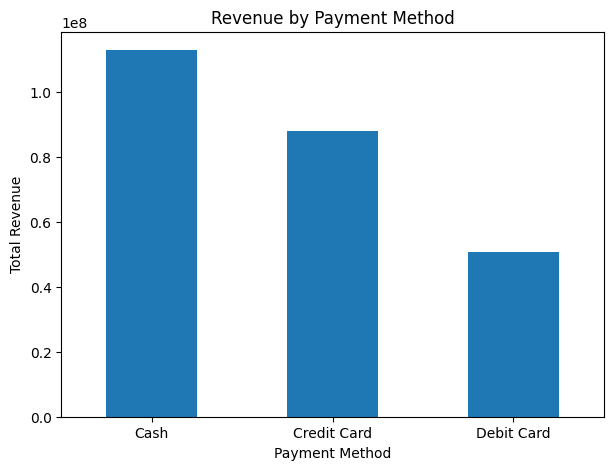

In [93]:
payment_revenue.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")

plt.xticks(rotation=0)

plt.show()

# Distribution Analysis

## Business Question

Is the **total_sales** variable normally distributed?

## Objective

Before selecting any statistical test, it is important to understand the distribution of the data.

Distribution analysis helps us:

- Examine the shape of the data.
- Detect skewness.
- Identify potential outliers.
- Decide whether to use parametric or non-parametric statistical tests.

# Distribution Analysis of Total Sales

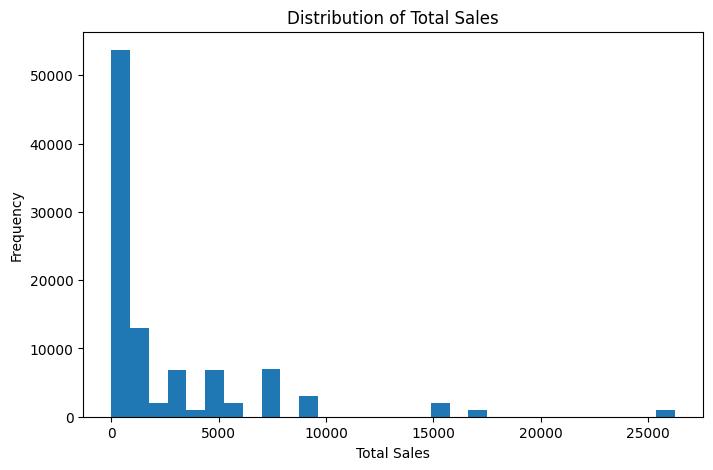

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["total_sales"], bins=30)

plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.show()

## Boxplot Analysis

The boxplot reveals several high-value outliers above the upper whisker.

These outliers represent customers who made exceptionally large purchases compared to the majority of transactions.

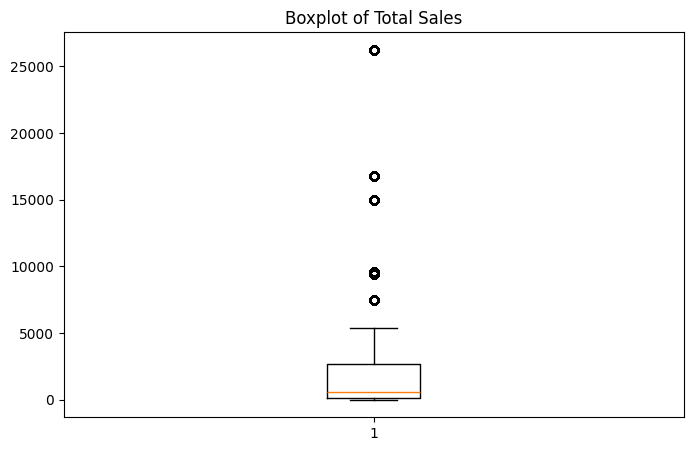

In [95]:
plt.figure(figsize=(8,5))

plt.boxplot(df["total_sales"])

plt.title("Boxplot of Total Sales")

plt.show()

## Business Insight

Most customers make low to medium-value purchases, while a small group generates significantly higher sales.

### Recommendations

- Identify high-value customers and offer loyalty rewards.
- Analyze large transactions to understand purchasing behavior.
- Create targeted marketing campaigns for premium customers.
- Monitor outliers to detect both business opportunities and unusual transactions.

# Correlation Analysis

## Objective

The objective of this analysis is to examine the relationships between numerical variables in the dataset.

Understanding these relationships helps businesses:

- Identify the factors that influence total sales.
- Discover patterns between customer age, quantity, price, and revenue.
- Support data-driven decision-making.
- Provide insights for predictive analytics.

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df[["age", "quantity", "price", "total_sales"]].corr()

correlation

,age,quantity,price,total_sales
age,1.000000,0.000667,0.001694,0.002731
quantity,0.000667,1.000000,0.344880,0.461173
price,0.001694,0.344880,1.000000,0.962372
total_sales,0.002731,0.461173,0.962372,1.000000


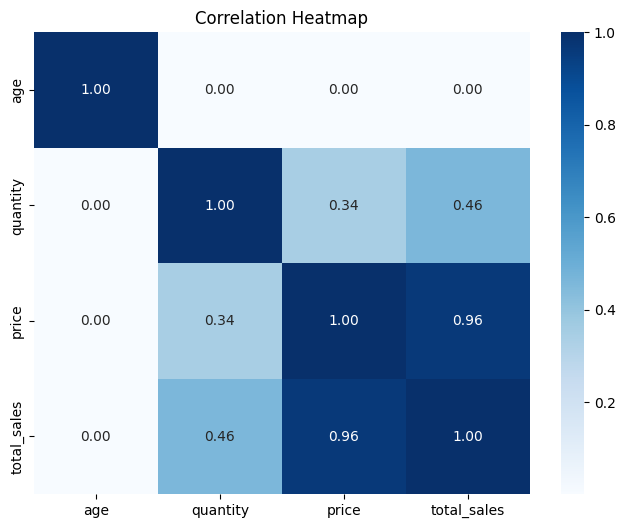

In [101]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Business Insight

The analysis suggests that increasing product value (price) has a much greater impact on revenue than customer age.

### Recommendations

- Focus marketing efforts on high-value products.
- Optimize pricing strategies to maximize revenue.
- Encourage customers to purchase multiple items through bundle offers.
- Customer segmentation should rely on purchasing behavior rather than age alone.

# Average Order Value (AOV) Analysis

## Objective

The objective of this analysis is to calculate the Average Order Value (AOV), which measures the average amount of revenue generated from each customer transaction.

AOV is an important business metric because it helps:

- Evaluate customer spending behavior.
- Measure sales performance.
- Support pricing and promotional strategies.
- Identify opportunities to increase average customer spending.

In [99]:
df["total_sales"].mean()

np.float64(2528.7892682264696)

## Business Insight

The current AOV provides a baseline for measuring customer spending.

### Recommendations

- Increase AOV through bundle offers and product recommendations.
- Introduce premium product options.
- Offer discounts above a minimum purchase amount.
- Track AOV over time to evaluate marketing and pricing strategies.

# Executive Summary

## Key Findings

- Clothing is the most purchased and highest revenue-generating product category.
- Female customers generated higher total revenue than male customers.
- Mall of Istanbul and Kanyon were the best-performing shopping malls.
- Cash was the most frequently used payment method.
- Customers aged 56–69 contributed the highest revenue.
- Price showed the strongest positive correlation with total sales.
- The Average Order Value (AOV) was approximately 2,529.
- Monthly revenue remained relatively stable before declining in the final period of the dataset.
This project demonstrates how Python and exploratory data analysis (EDA) can be used to transform raw transactional data into meaningful business insights. The findings can support strategic decision-making in marketing, inventory management, customer segmentation, and revenue optimization.

# Final Business Recommendations

Based on the analysis, the following recommendations are suggested:

- Focus marketing efforts on high-performing product categories such as Clothing.
- Strengthen customer loyalty programs for high-value customers.
- Improve inventory management based on demand patterns.
- Increase promotions during low-sales periods.
- Continue monitoring monthly revenue trends to support business planning.
- Use customer segmentation to deliver personalized marketing campaigns.
- Optimize pricing strategies to maximize revenue and profitability.